In [1]:
import os
os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache")
os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"
os.environ["CRDS_CONTEXT"] = "jwst_1460.pmap"

from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from astroquery.svo_fps import SvoFps
from astropy.wcs import WCS
from astropy.io import fits

def get_mag(catalog, ww, filtername='f140m'):
    print(ww.proj_plane_pixel_area())
    flux= (catalog['flux_fit_' + filtername] * u.MJy/u.sr * ww.proj_plane_pixel_area()).to(u.Jy)
    eflux_jy = (catalog['flux_err_' + filtername] * u.MJy/u.sr *  ww.proj_plane_pixel_area()).to(u.Jy)

    jfilts = SvoFps.get_filter_list('JWST')
    jfilts.add_index('filterID')
    zeropoint = u.Quantity(jfilts.loc[f'JWST/NIRCam.{filtername.upper()}']['ZeroPoint'], u.Jy)
    abmag = -2.5 * np.log10(flux / zeropoint) * u.mag
    abmag_err = 2.5 / np.log(10) * np.abs(eflux_jy / flux) * u.mag

    return abmag, abmag_err



catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_nircam_indivexp_merged_dao_refined.fits')

image_filenames ={
    "f140m": "/orange/adamginsburg/jwst/w51/F140M/pipeline/jw06151-o001_t001_nircam_clear-f140m-merged_i2d.fits",
    "f150w": "/orange/adamginsburg/jwst/w51/F150W/pipeline/jw06151-o001_t001_nircam_clear-f150w-merged_i2d.fits",
    "f162m": "/orange/adamginsburg/jwst/w51/F162M/pipeline/jw06151-o001_t001_nircam_clear-f162m-merged_i2d.fits",
    "f182m": "/orange/adamginsburg/jwst/w51/F182M/pipeline/jw06151-o001_t001_nircam_clear-f182m-merged_i2d.fits",
    "f187n": "/orange/adamginsburg/jwst/w51/F187N/pipeline/jw06151-o001_t001_nircam_clear-f187n-merged_i2d.fits",
    "f210m": "/orange/adamginsburg/jwst/w51/F210M/pipeline/jw06151-o001_t001_nircam_clear-f210m-merged_i2d.fits",
    "f335m": "/orange/adamginsburg/jwst/w51/F335M/pipeline/jw06151-o001_t001_nircam_clear-f335m-merged_i2d.fits",
    "f360m": "/orange/adamginsburg/jwst/w51/F360M/pipeline/jw06151-o001_t001_nircam_clear-f360m-merged_i2d.fits",
    "f405n": "/orange/adamginsburg/jwst/w51/F405N/pipeline/jw06151-o001_t001_nircam_clear-f405n-merged_i2d.fits",
    "f410m": "/orange/adamginsburg/jwst/w51/F410M/pipeline/jw06151-o001_t001_nircam_clear-f410m-merged_i2d.fits", # weird, the filename is different from what is downloaded with the STScI pipeline...
    "f480m": "/orange/adamginsburg/jwst/w51/F480M/pipeline/jw06151-o001_t001_nircam_clear-f480m-merged_i2d.fits",
    "f560w": "/orange/adamginsburg/jwst/w51/F560W/pipeline/jw06151-o002_t001_miri_f560w_i2d.fits",
    "f770w": "/orange/adamginsburg/jwst/w51/F770W/pipeline/jw06151-o002_t001_miri_f770w_i2d.fits",
    "f1000w": "/orange/adamginsburg/jwst/w51/F1000W/pipeline/jw06151-o002_t001_miri_f1000w_i2d.fits",
    "f1280w": "/orange/adamginsburg/jwst/w51/F1280W/pipeline/jw06151-o002_t001_miri_f1280w_i2d.fits",
    "f1500w": "/orange/adamginsburg/jwst/w51/F1500W/pipeline/jw06151-o002_t001_miri_f1500w_i2d.fits",
    "f2100w": "/orange/adamginsburg/jwst/w51/F2100W/pipeline/jw06151-o002_t001_miri_f2100w_i2d.fits",
    
}

f140m_header = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
f162m_header = fits.getheader(image_filenames['f162m'], ext=('SCI', 1))
f182m_header = fits.getheader(image_filenames['f182m'], ext=('SCI', 1))
f210m_header = fits.getheader(image_filenames['f210m'], ext=('SCI', 1))
f335m_header = fits.getheader(image_filenames['f335m'], ext=('SCI', 1))
f360m_header = fits.getheader(image_filenames['f360m'], ext=('SCI', 1))
f405n_header = fits.getheader(image_filenames['f405n'], ext=('SCI', 1))
f410m_header = fits.getheader(image_filenames['f410m'], ext=('SCI', 1))
f480m_header = fits.getheader(image_filenames['f480m'], ext=('SCI', 1))



f140m_mag = get_mag(catalog, WCS(f140m_header), filtername='f140m')
f162m_mag = get_mag(catalog, WCS(f162m_header), filtername='f162m')
f182m_mag = get_mag(catalog, WCS(f182m_header), filtername='f182m')
f210m_mag = get_mag(catalog, WCS(f210m_header), filtername='f210m')
f335m_mag = get_mag(catalog, WCS(f335m_header), filtername='f335m')
f360m_mag = get_mag(catalog, WCS(f360m_header), filtername='f360m')
f405n_mag = get_mag(catalog, WCS(f405n_header), filtername='f405n')
f410m_mag = get_mag(catalog, WCS(f410m_header), filtername='f410m')
f480m_mag = get_mag(catalog, WCS(f480m_header), filtername='f480m')





Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T14:19:06.870' from MJD-AVG.
Set DATE-END to '2025-05-06T14:41:02.194' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.220336 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610512569.543 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T15:11:59.611' from MJD-AVG.
Set DATE-END to '2025-05-06T15:35:36.878' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.237189 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610816321.821 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-05-06T16:06:02.819' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE

7.525093728112705e-11 deg2
7.527908837786718e-11 deg2
7.525104772361525e-11 deg2
7.52514718037244e-11 deg2
3.053877779107583e-10 deg2
3.0536898714608487e-10 deg2
3.056563930691893e-10 deg2
3.0541063885182936e-10 deg2
3.054668262896466e-10 deg2


Set DATE-AVG to '2025-05-06T16:59:22.421' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


0.005329104616543183 Jy 3.5477713112490935e-09 Jy 4.154461296548714e-06 Jy


Set DATE-AVG to '2025-05-06T16:06:02.819' from MJD-AVG.
Set DATE-END to '2025-05-06T16:29:39.435' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -25.254571 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611129611.449 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


(array([ 22.,  21.,  36.,  48.,  59., 101.,  80., 105., 113., 111., 134.,
        124., 146., 159., 177., 204., 264., 259., 307., 325., 344., 344.,
        375., 376., 401., 359., 397., 400., 417., 416., 424., 425., 429.,
        397., 425., 408., 412., 365., 403., 384., 402., 412., 376., 395.,
        372., 357., 361., 324., 296., 339., 312., 300., 277., 307., 258.,
        279., 270., 262., 231., 249., 226., 235., 241., 218., 247., 181.,
        196., 189., 188., 164., 156., 166., 136., 137., 115., 112., 113.,
        111., 111.,  99.,  78.,  83.,  75.,  83.,  76.,  77.,  58.,  56.,
         48.,  50.,  39.,  46.,  41.,  44.,  26.,  31.,  16.,  16.,  17.]),
 array([1.00000000e-07, 1.09749877e-07, 1.20450354e-07, 1.32194115e-07,
        1.45082878e-07, 1.59228279e-07, 1.74752840e-07, 1.91791026e-07,
        2.10490414e-07, 2.31012970e-07, 2.53536449e-07, 2.78255940e-07,
        3.05385551e-07, 3.35160265e-07, 3.67837977e-07, 4.03701726e-07,
        4.43062146e-07, 4.86260158e-07, 5.33

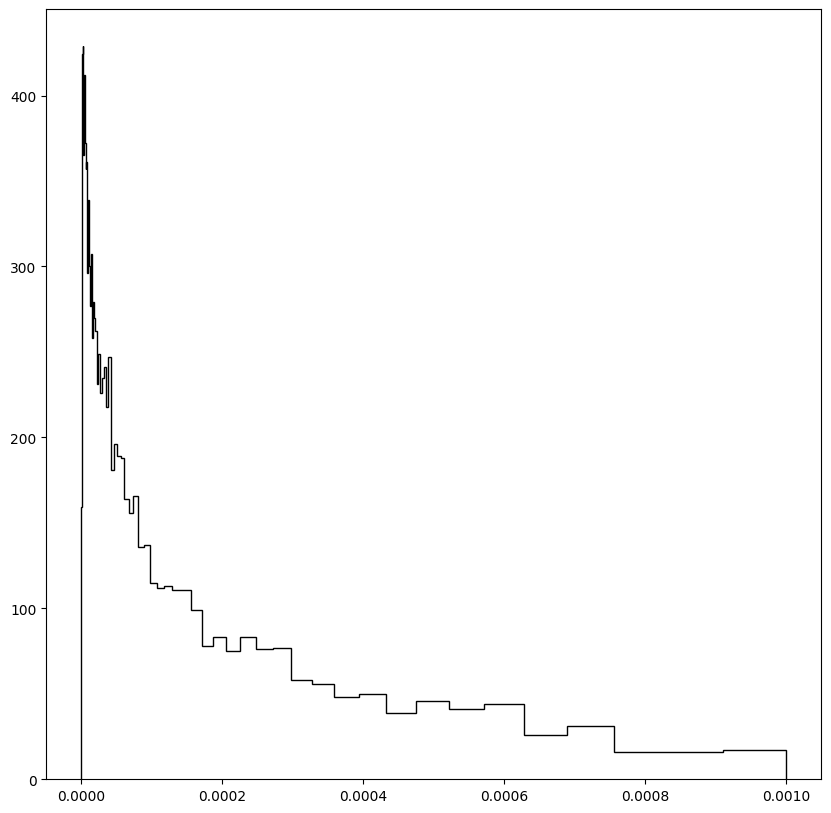

In [12]:
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
f210_flux = (catalog['flux_fit_f210m'] * u.MJy/u.sr * WCS(f210m_header).proj_plane_pixel_area()).to(u.Jy)
print(np.nanmax(f210_flux), np.nanmin(f210_flux[f210_flux>0]), np.median(f210_flux[f210_flux>0]))
ax1.hist(f210_flux[f210_flux>0].value, bins=np.logspace(-7, -3, 100), histtype='step', color='black', label='F210M')

In [3]:
dd

NameError: name 'dd' is not defined

4.05 um 4.1 um 3.35 um 3.6 um
4.05 um 4.1 um 3.35 um 3.6 um
4.045014245014246 3.908818011257037 6.219356343283582 5.441025641025642


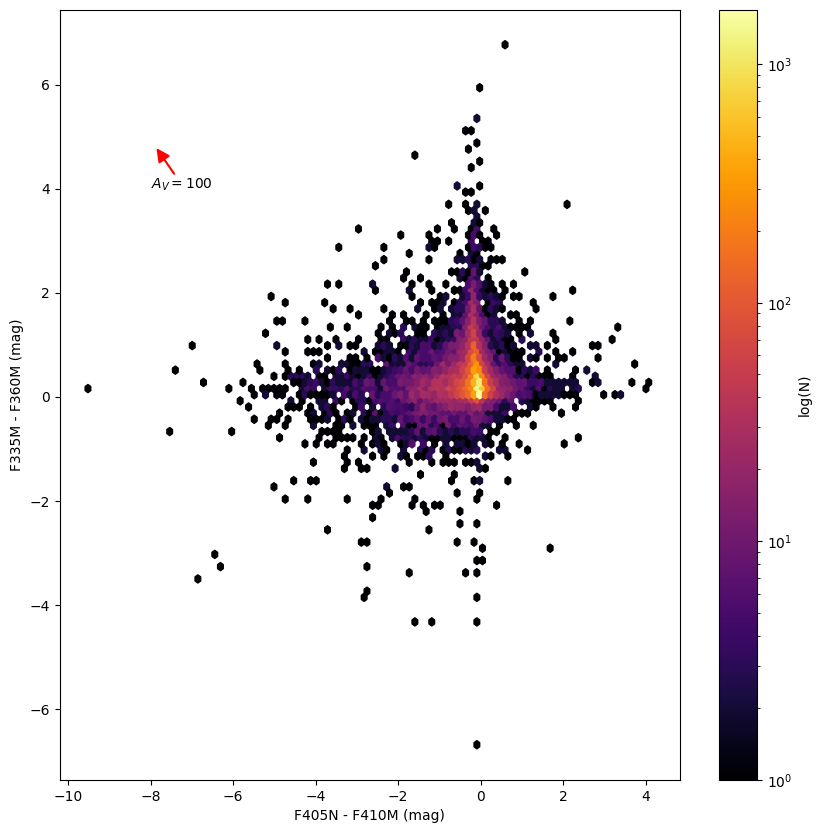

In [ ]:
from dust_extinction.averages import RL85_MWGC
from dust_extinction.parameter_averages import CCM89
ext = RL85_MWGC()
def plot_extvec_ccd(ax, color1, color2, ext=RL85_MWGC(), extvec_scale=200,
                    start=(0, 0),
                    color='y', head_width=0.5):
    def get_wave(c):
        if c == '410m405': return 4.10*u.um
        if c == '405m410': return 4.05*u.um
        if c == 'Hmag': return 1.634*u.um
        if c == 'Ksmag': return 2.143527*u.um
        return int(c[1:-1])/100*u.um

    w1 = get_wave(color1[0])
    w2 = get_wave(color1[1])
    w3 = get_wave(color2[0])
    w4 = get_wave(color2[1])

    if w1 > w2:
        w1, w2 = w2, w1
        color1 = color1[::-1]
    if w3 > w4:
        w3, w4 = w4, w3
        color2 = color2[::-1]
    print(w1,w2,w3,w4)

    # Only plot if all are in valid range
    try:
        e_1 = ext(1/w1) * extvec_scale
        e_2 = ext(1/w2) * extvec_scale
        e_3 = ext(1/w3) * extvec_scale
        e_4 = ext(1/w4) * extvec_scale
    except ValueError as e:
        print(f"Extinction vector not plotted: {e}")
        return
    print(w1,w2,w3,w4)
    print(e_1, e_2, e_3, e_4)
    ax.annotate(f'$A_V={extvec_scale}$', xy=(start[0] + (e_1 - e_2), start[1] + (e_3 - e_4)),
                xytext=(start[0], start[1]),
                arrowprops=dict(arrowstyle='-|>', color=color,
                                shrinkA=0, shrinkB=0,
                                mutation_scale=20, linewidth=1.5))
    ax.plot([], [], color=color, marker='>', markersize=8,
            label=f'$A_V={extvec_scale}$', linestyle='-', linewidth=2)

fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
x = (f405n_mag[0]-f410m_mag[0]).value
y = (f335m_mag[0]-f360m_mag[0]).value
hb = ax1.hexbin(x, y, gridsize=100, cmap='inferno', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=ax1, label='log(N)')
ax1.set_xlabel('F405N - F410M (mag)')
ax1.set_ylabel('F335M - F360M (mag)')
plot_extvec_ccd(ax1, color1=('f405n','f410m'), color2=('f335m','f360m'), ext=ext, extvec_scale=100, start=(-8,4), color='r')

1.4 um 1.62 um 3.6 um 4.8 um
1.4 um 1.62 um 3.6 um 4.8 um
7.0412946428571415 5.4357638888888875 1.6323076923076927 0.69


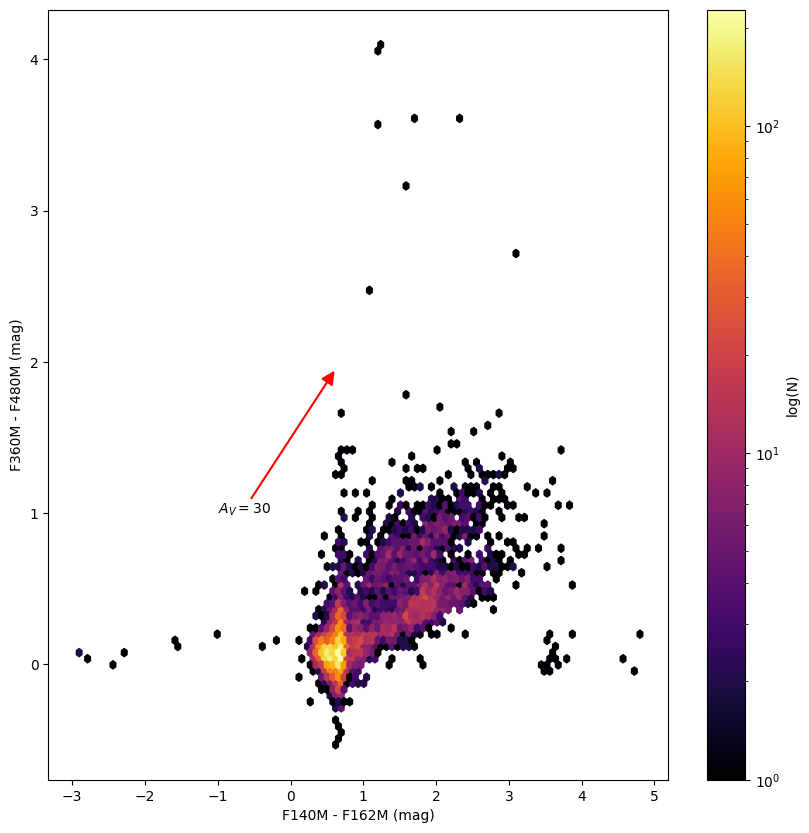

In [ ]:
#F140m-f162m vs f360m-f480m
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
x = (f140m_mag[0]-f162m_mag[0]).value
y = (f360m_mag[0]-f480m_mag[0]).value
hb = ax1.hexbin(x, y, gridsize=100, cmap='inferno', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=ax1, label='log(N)')
ax1.set_xlabel('F140M - F162M (mag)')
ax1.set_ylabel('F360M - F480M (mag)')
plot_extvec_ccd(ax1, color1=('f140m','f162m'), color2=('f360m','f480m'), ext=ext, extvec_scale=30, start=(-1,1), color='r')

1.4 um 1.62 um 2.1 um 4.8 um
1.4 um 1.62 um 2.1 um 4.8 um
7.0412946428571415 5.4357638888888875 3.6726315789473687 0.69


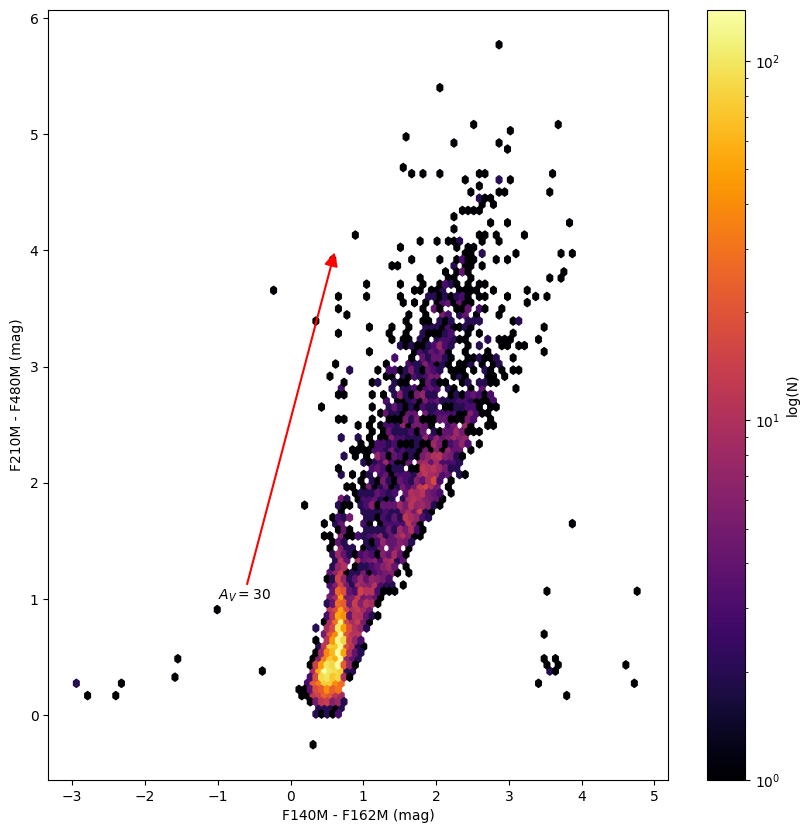

In [ ]:
#F140m-f162m vs f210m-f480m
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
x = (f140m_mag[0]-f162m_mag[0]).value
y = (f210m_mag[0]-f480m_mag[0]).value
hb = ax1.hexbin(x, y, gridsize=100, cmap='inferno', mincnt=1, bins='log')
cb = fig.colorbar(hb, ax=ax1, label='log(N)')
ax1.set_xlabel('F140M - F162M (mag)')
ax1.set_ylabel('F210M - F480M (mag)')
plot_extvec_ccd(ax1, color1=('f140m','f162m'), color2=('f210m','f480m'), ext=ext, extvec_scale=30, start=(-1,1), color='r')

 col1    col2    col3       col4          col5       col6   col7   col8   col9 col10 col11 col12  col13 col14 col15 col16 col17 col18   col19   col20  col21   col22    col23     col24     col25   col26   col27   col28  col29  col30  col31  col32  col33  col34  col35  col36  col37  col38  col39  col40  col41  col42  col43  col44  col45  col46  col47  col48  col49  col50 
------ ------- ------- -------------- ------------ ------- ------ ------ ----- ----- ----- ------ ----- ----- ----- ----- ----- ----- --------- ----- -------- ------ --------- --------- --------- ------ ------- ------- ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------ ------
0.0207 0.15867     6.0   0.0908484459 1.0897678296   0.091  -1.33 3.4326 3.409     0   0.0  0.545   0.0   0.0   0.0   0.0   0.0    -1 -3.89e-14   0.0   0.6936 0.2855  0.003749  0.001011  0.009172   -1.0 0.02085   8.095  9.712  7.478  6.249  5.749  5.324 

(-0.5, 2.0)

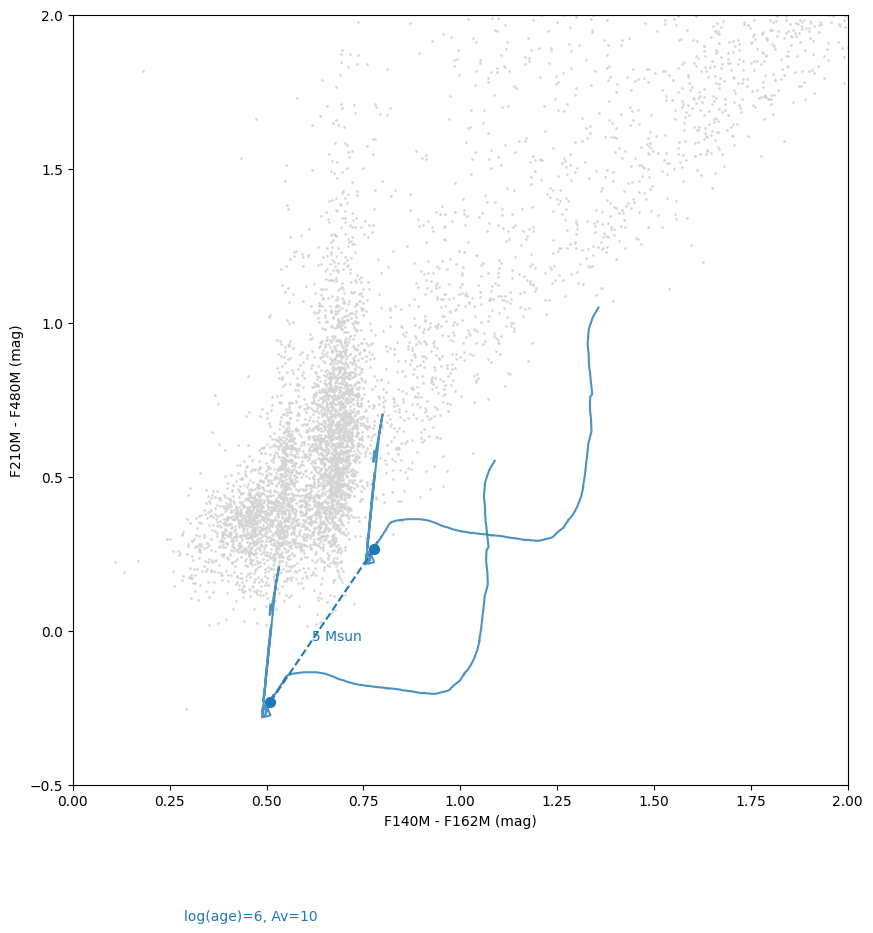

In [ ]:
from astropy.table import Table
import crds
parsec_av0 = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec_av0.pprint(max_width=-1, max_lines=-1)   
m_init = parsec_av0['col4']  
parsec_av0 = parsec_av0[m_init<300]              
logage_av0 = parsec_av0['col3']
mass_av0 = parsec_av0['col6']

F140Mmag_av0 = parsec_av0['col39'] + 5*np.log10(5400)-5
F162Mmag_av0 = parsec_av0['col40']+ 5*np.log10(5400)-5
F182Mmag_av0 = parsec_av0['col41']+ 5*np.log10(5400)-5
F210Mmag_av0 = parsec_av0['col42']+ 5*np.log10(5400)-5
F335Mmag_av0 = parsec_av0['col45']+ 5*np.log10(5400)-5
F360Mmag_av0 = parsec_av0['col46']+ 5*np.log10(5400)-5
F410Mmag_av0 = parsec_av0['col47']+ 5*np.log10(5400)-5
F480Mmag_av0 = parsec_av0['col50']+ 5*np.log10(5400)-5

parsec_av5 = Table.read('/home/t.yoo/parsec_av5.txt', format='ascii')
logage_av5 = parsec_av5['col3']
mass_av5 = parsec_av5['col6']
F140Mmag_av5 = parsec_av5['col39']+ 5*np.log10(5400)-5
F162Mmag_av5 = parsec_av5['col40'] + 5*np.log10(5400)-5
F182Mmag_av5 = parsec_av5['col41']+ 5*np.log10(5400)-5
F210Mmag_av5 = parsec_av5['col42']+ 5*np.log10(5400)-5
F335Mmag_av5 = parsec_av5['col45']+ 5*np.log10(5400)-5
F360Mmag_av5 = parsec_av5['col46']+ 5*np.log10(5400)-5
F410Mmag_av5 = parsec_av5['col47']+ 5*np.log10(5400)-5
F480Mmag_av5 = parsec_av5['col50']+ 5*np.log10(5400)-5

parsec_av10 = Table.read('/home/t.yoo/parsec_av10.txt', format='ascii')
logage_av10 = parsec_av10['col3']
mass_av10 = parsec_av10['col6']
F140Mmag_av10 = parsec_av10['col39']+ 5*np.log10(5400)-5
F162Mmag_av10 = parsec_av10['col40']+ 5*np.log10(5400)-5
F182Mmag_av10 = parsec_av10['col41']+ 5*np.log10(5400)-5
F210Mmag_av10 = parsec_av10['col42']+ 5*np.log10(5400)-5
F335Mmag_av10 = parsec_av10['col45']+ 5*np.log10(5400)-5
F360Mmag_av10 = parsec_av10['col46']+ 5*np.log10(5400)-5
F410Mmag_av10 = parsec_av10['col47']+ 5*np.log10(5400)-5
F480Mmag_av10 = parsec_av10['col50']+ 5*np.log10(5400)-5


import asdf

def load_nircam_abvega_offsets(asdf_path, filter_name):
    """
    Load JWST NIRCam AB–Vega offset reference file (ASDF) 
    and return a dict mapping filter names → offsets (in mag).
    
    The ASDF file is expected to follow the JWST CRDS “FILTEROFFSET”
    (or an equivalent zeropoint offset) schema.
    """
    with asdf.open(asdf_path) as af:
        tree = af.tree
        # The offsets might live under some key, e.g. tree["offsets"] or tree["filters"]
        # Inspect the file structure to adapt:
        # For example, tree["data"] or tree["offsets"] or tree["filters"]
        # Here’s a guess:
        tabs = tree.get("abvega_offset", None)
        idx = np.where((tabs['filter'] == filter_name.upper()) & (tabs['pupil']=='CLEAR'))[0]
        if len(idx)!=1:
            idx = np.where(tabs['pupil']==filter_name.upper())[0]
        tabs.pprint(max_width=-1, max_lines=-1)
        print(idx)
        return tabs['abvega_offset'][idx].item()


def vega_to_ab(vega_mag, filter_name, asdf_path):
    """
    Convert Vega magnitude to AB magnitude using offset dictionary.
    """
    offset = load_nircam_abvega_offsets(asdf_path, filter_name)
   
    return vega_mag + offset

"""
from astropy.io import fits
hdr = fits.getheader(image_filenames['f140m'], ext=('SCI', 1))
print(hdr)
crds_params = {
    "INSTRUME": "NIRCAM",
    "DETECTOR": 'NRCA1',  # or NRCB5, etc.
    "META.OBSERVATION.DATE": hdr['DATE-OBS']  # Use the actual observation date
}

# Path or URL to your .rmap file
ref_file = crds.getreferences(crds_params, ["abvegaoffset"], context="jwst_1460.pmap")

rmap = crds.rmap.load_mapping(ref_file["nircam_abvegaoffset"]
)
references = rmap.get_data()
"""
#asdf_file = crds.get_reference_file("jwst", refname)
asdf_file = '/home/t.yoo/w51/w51_nircam/jwst_nircam_abvegaoffset_0002.asdf'
F140M_avmag_av0 = vega_to_ab(F140Mmag_av0, 'F140M', asdf_file)
F162M_avmag_av0 = vega_to_ab(F162Mmag_av0, 'F162M', asdf_file)
F182M_avmag_av0 = vega_to_ab(F182Mmag_av0, 'F182M', asdf_file)
F210M_avmag_av0 = vega_to_ab(F210Mmag_av0, 'F210M', asdf_file)
F335M_avmag_av0 = vega_to_ab(F335Mmag_av0, 'F335M', asdf_file)
F360M_avmag_av0 = vega_to_ab(F360Mmag_av0, 'F360M', asdf_file)
F410M_avmag_av0 = vega_to_ab(F410Mmag_av0, 'F410M', asdf_file)
F480M_avmag_av0 = vega_to_ab(F480Mmag_av0, 'F480M', asdf_file)

F140M_avmag_av5 = vega_to_ab(F140Mmag_av5, 'F140M', asdf_file)
F162M_avmag_av5 = vega_to_ab(F162Mmag_av5, 'F162M', asdf_file)
F182M_avmag_av5 = vega_to_ab(F182Mmag_av5, 'F182M', asdf_file)
F210M_avmag_av5 = vega_to_ab(F210Mmag_av5, 'F210M', asdf_file)
F335M_avmag_av5 = vega_to_ab(F335Mmag_av5, 'F335M', asdf_file)
F360M_avmag_av5 = vega_to_ab(F360Mmag_av5, 'F360M', asdf_file)
F410M_avmag_av5 = vega_to_ab(F410Mmag_av5, 'F410M', asdf_file)
F480M_avmag_av5 = vega_to_ab(F480Mmag_av5, 'F480M', asdf_file)

F140M_avmag_av10 = vega_to_ab(F140Mmag_av10, 'F140M', asdf_file)
F162M_avmag_av10 = vega_to_ab(F162Mmag_av10, 'F162M', asdf_file)
F182M_avmag_av10 = vega_to_ab(F182Mmag_av10, 'F182M', asdf_file)
F210M_avmag_av10 = vega_to_ab(F210Mmag_av10, 'F210M', asdf_file)
F335M_avmag_av10 = vega_to_ab(F335Mmag_av10, 'F335M', asdf_file)
F360M_avmag_av10 = vega_to_ab(F360Mmag_av10, 'F360M', asdf_file)
F410M_avmag_av10 = vega_to_ab(F410Mmag_av10, 'F410M', asdf_file)
F480M_avmag_av10 = vega_to_ab(F480Mmag_av10, 'F480M', asdf_file)

print(F140M_avmag_av5-F162M_avmag_av5)
# conver vegaMag to abmag
#mag_ab = -6.10 - 2.5 * np.log10(flux*pixel_scale)
#mag_vega = -2.5*np.log10(flux*pixel_scale)

fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
x = (f140m_mag[0]-f162m_mag[0]).value
y = (f210m_mag[0]-f480m_mag[0]).value
hb = ax1.scatter(x, y, color='lightgray', s=1, alpha=0.8)
ax1.set_xlabel('F140M - F162M (mag)')
ax1.set_ylabel('F210M - F480M (mag)')
plot_extvec_ccd(ax1, color1=('f140m','f162m'), color2=('f210m','f480m'), ext=ext, extvec_scale=10, start=(2,0), color='r')

ageset = np.unique(logage_av0)

#for i, age in enumerate(ageset):
#    idx = logage_av0 == age
#    if np.sum(idx)>0:
#        ax1.plot((F140M_avmag_av0[idx]-F162M_avmag_av0[idx]), (F210M_avmag_av0[idx]-F480M_avmag_av0[idx]) , color=f'C{i}', alpha=0.8)
#        ax1.text((F140M_avmag_av0[idx]-F162M_avmag_av0[idx])[0], (F210M_avmag_av0[idx]-F480M_avmag_av0[idx])[0], f'log(age)={age}', color=f'C{i}')
ageset = [6]
for i, age in enumerate(ageset):
    idx = logage_av0 == age
    if np.sum(idx)>0:
        ax1.plot((F140M_avmag_av0[idx]-F162M_avmag_av0[idx]), (F210M_avmag_av0[idx]-F480M_avmag_av0[idx]) , color=f'C{i}', alpha=0.8)
        ax1.text((F140M_avmag_av0[idx]-F162M_avmag_av0[idx])[0], (F210M_avmag_av0[idx]-F480M_avmag_av0[idx])[0], f'log(age)={age}, Av=10', color=f'C{i}')

        ax1.plot((F140M_avmag_av0[idx]-F162M_avmag_av0[idx]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15), (F210M_avmag_av0[idx]-F480M_avmag_av0[idx]+(ext(1/2.1/u.um)-ext(1/4.8/u.um))*15) , color=f'C{i}', alpha=0.8)
        ax1.plot((F140M_avmag_av0[idx]-F162M_avmag_av0[idx]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20), (F210M_avmag_av0[idx]-F480M_avmag_av0[idx]+(ext(1/2.1/u.um)-ext(1/4.8/u.um))*20) , color=f'C{i}', alpha=0.8)
        idx_5msun = np.argmin(np.abs(mass_av0[idx]-5))
        idx_10msun = np.argmin(np.abs(mass_av0[idx]-10))
        ax1.scatter((F140M_avmag_av0[idx][idx_5msun]-F162M_avmag_av0[idx][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15), (F210M_avmag_av0[idx][idx_5msun]-F480M_avmag_av0[idx][idx_5msun]+(ext(1/2.1/u.um)-ext(1/4.8/u.um))*15), color=f'C{i}', marker='o', s=50, label=f'5 Msun, Av=15')
        ax1.scatter((F140M_avmag_av0[idx][idx_5msun]-F162M_avmag_av0[idx][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20), (F210M_avmag_av0[idx][idx_5msun]-F480M_avmag_av0[idx][idx_5msun]+(ext(1/2.1/u.um)-ext(1/4.8/u.um))*20), color=f'C{i}', marker='o', s=50, label=f'5 Msun, Av=20')
        ax1.plot([F140M_avmag_av0[idx][idx_5msun]-F162M_avmag_av0[idx][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15, F140M_avmag_av0[idx][idx_5msun]-F162M_avmag_av0[idx][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20],
        [F210M_avmag_av0[idx][idx_5msun]-F480M_avmag_av0[idx][idx_5msun]+(ext(1/2.1/u.um)-ext(1/4.8/u.um))*15, F210M_avmag_av0[idx][idx_5msun]-F480M_avmag_av0[idx][idx_5msun]+(ext(1/2.1/u.um)-ext(1/4.8/u.um))*20], color=f'C{i}', linestyle='dashed')
        ax1.text((F140M_avmag_av0[idx][idx_5msun]-F162M_avmag_av0[idx][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*17), (F210M_avmag_av0[idx][idx_5msun]-F480M_avmag_av0[idx][idx_5msun]+(ext(1/2.1/u.um)-ext(1/4.8/u.um))*17), f'5 Msun', color=f'C{i}')

#for i, age in enumerate(ageset):
#    idx = logage_av5 == age
#    if np.sum(idx)>0:
#        ax1.plot((F140M_avmag_av5[idx]-F162M_avmag_av5[idx]), (F210M_avmag_av5[idx]-F480M_avmag_av5[idx]) , color=f'C{i}', alpha=0.1, linestyle='dashed')
#        ax1.text((F140M_avmag_av5[idx]-F162M_avmag_av5[idx])[0], (F210M_avmag_av5[idx]-F480M_avmag_av5[idx])[0], f'log(age)={age}, Av=30', color=f'C{i}')
ax1.set_xlim(0, 2)
ax1.set_ylim(-0.5, 2)


1.4 um 1.62 um 1.82 um 2.1 um
1.4 um 1.62 um 1.82 um 2.1 um
2.347098214285714 1.8119212962962958 1.5208097165991898 1.2242105263157896


(0.0, 0.7)

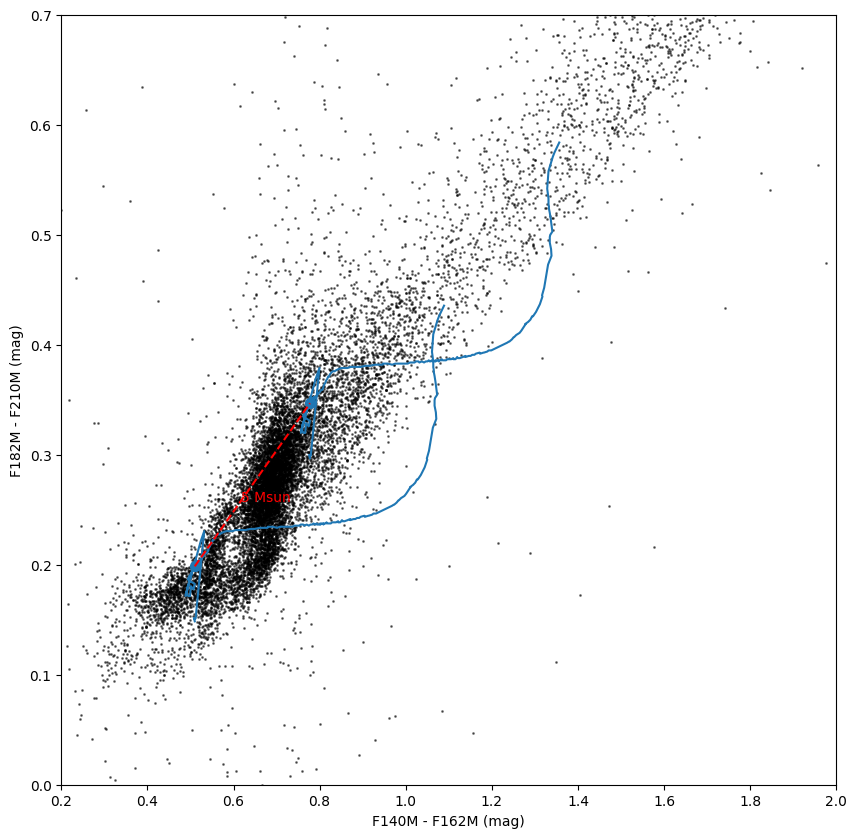

In [ ]:
#140 - 162 vs 182 - 210
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
x = (f140m_mag[0]-f162m_mag[0]).value
y = (f182m_mag[0]-f210m_mag[0]).value
hb = ax1.scatter(x, y, s=1, color='k', alpha=0.5)
#cb = fig.colorbar(hb, ax=ax1, label='log(N)')
ax1.set_xlabel('F140M - F162M (mag)')
ax1.set_ylabel('F182M - F210M (mag)')
plot_extvec_ccd(ax1, color1=('f140m','f162m'), color2=('f182m','f210m'), ext=ext, extvec_scale=10, start=(2,0), color='r')

ageset = np.unique(logage_av0)
ageset = [6]
for i, age in enumerate(ageset):
    idx = logage_av0 == age
    if np.sum(idx)>0:
        ax1.plot((F140M_avmag_av0[idx]-F162M_avmag_av0[idx]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15), (F182M_avmag_av0[idx]-F210M_avmag_av0[idx]+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*15) , color=f'C{i}')
        ax1.plot((F140M_avmag_av0[idx]-F162M_avmag_av0[idx]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20), (F182M_avmag_av0[idx]-F210M_avmag_av0[idx]+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*20) , color=f'C{i}')
        idx_5msun = np.argmin(np.abs(mass_av0[idx]-5))
        idx_10msun = np.argmin(np.abs(mass_av0[idx]-10))
        ax1.scatter((F140M_avmag_av0[idx][idx_5msun]-F162M_avmag_av0[idx][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15), (F182M_avmag_av0[idx][idx_5msun]-F210M_avmag_av0[idx][idx_5msun]+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*15), color=f'C{i}', marker='o', s=50, label=f'5 Msun, Av=15')
        ax1.scatter((F140M_avmag_av0[idx][idx_5msun]-F162M_avmag_av0[idx][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20), (F182M_avmag_av0[idx][idx_5msun]-F210M_avmag_av0[idx][idx_5msun]+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*20), color=f'C{i}', marker='o', s=50, label=f'5 Msun, Av=20')
        ax1.plot([F140M_avmag_av0[idx][idx_5msun]-F162M_avmag_av0[idx][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15, F140M_avmag_av0[idx][idx_5msun]-F162M_avmag_av0[idx][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20],
        [F182M_avmag_av0[idx][idx_5msun]-F210M_avmag_av0[idx][idx_5msun]+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*15, F182M_avmag_av0[idx][idx_5msun]-F210M_avmag_av0[idx][idx_5msun]+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*20], color='r', linestyle='dashed')
        ax1.text((F140M_avmag_av0[idx][idx_5msun]-F162M_avmag_av0[idx][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*17), (F182M_avmag_av0[idx][idx_5msun]-F210M_avmag_av0[idx][idx_5msun]+(ext(1/1.82/u.um)-ext(1/2.10/u.um))*17), f'5 Msun', color='red')

ax1.set_xlim(0.2,2)
ax1.set_ylim(0,0.7)

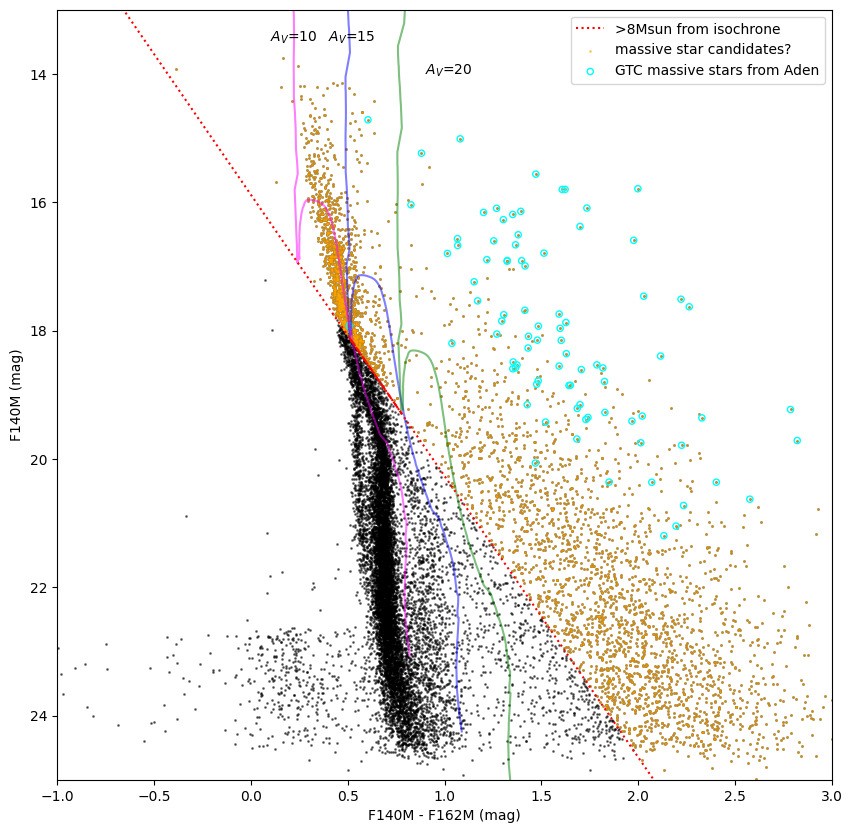

In [ ]:
from astropy.coordinates import SkyCoord

tab_gtc_matched = Table.read('/orange/adamginsburg/w51/TaehwaYoo/massive_star_table_jwstmatched.fits')
tab_gtc_matched_skycoord = SkyCoord(ra=tab_gtc_matched['jwst_matched_ra']*u.deg, dec=tab_gtc_matched['jwst_matched_dec']*u.deg, frame='icrs')
# For catalog
ra = catalog['skycoord'].ra
dec = catalog['skycoord'].dec
valid = (~np.isnan(ra)) & (~np.isnan(dec))
catalog_skycoord_valid = SkyCoord(ra=ra[valid], dec=dec[valid], frame='icrs')

# For GTC matched table
ra_gtc = tab_gtc_matched['jwst_matched_ra']
dec_gtc = tab_gtc_matched['jwst_matched_dec']
valid_gtc = (~np.isnan(ra_gtc)) & (~np.isnan(dec_gtc))
tab_gtc_matched_skycoord_valid = SkyCoord(ra=ra_gtc[valid_gtc]*u.deg, dec=dec_gtc[valid_gtc]*u.deg, frame='icrs')

# Now match only valid entries
idx, d2d, d3d = catalog_skycoord_valid.match_to_catalog_sky(tab_gtc_matched_skycoord_valid)
reverse_idx, reverse_d2d, reverse_d3d = tab_gtc_matched_skycoord_valid.match_to_catalog_sky(catalog_skycoord_valid)
real_reverse_matched = reverse_d2d < 0.05*u.arcsec


#F140 vs f140-f162
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
x = (f140m_mag[0]-f162m_mag[0]).value
y = f140m_mag[0].value
hb = ax1.scatter(x, y, s=1, color='k', alpha=0.5)
#cb = fig.colorbar(hb, ax=ax1, label='log(N)')
ax1.set_xlabel('F140M - F162M (mag)')
ax1.set_ylabel('F140M (mag)')
for i, age in enumerate(ageset):
    idx_age = logage_av0 == age

    ax1.plot((F140M_avmag_av0[idx_age]-F162M_avmag_av0[idx_age]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15), (F140M_avmag_av0[idx_age]+(ext(1/1.4/u.um))*15) , color='blue', alpha=0.5)
    ax1.plot((F140M_avmag_av0[idx_age]-F162M_avmag_av0[idx_age]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20), (F140M_avmag_av0[idx_age]+(ext(1/1.4/u.um))*20) , color='green', alpha=0.5)
    ax1.plot((F140M_avmag_av0[idx_age]-F162M_avmag_av0[idx_age]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*10), (F140M_avmag_av0[idx_age]+(ext(1/1.4/u.um))*10) , color='magenta', alpha=0.5)
    idx_8msun = np.argmin(np.abs(mass_av0[idx_age]-8))
    x_av15_8msun = F140M_avmag_av0[idx_age][idx_5msun]-F162M_avmag_av0[idx_age][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15
    y_av15_8msun = F140M_avmag_av0[idx_age][idx_5msun]+(ext(1/1.4/u.um))*15
    x_av20_8msun = F140M_avmag_av0[idx_age][idx_5msun]-F162M_avmag_av0[idx_age][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20
    y_av20_8msun = F140M_avmag_av0[idx_age][idx_5msun]+(ext(1/1.4/u.um))*20
    ax1.plot([x_av15_8msun, x_av20_8msun], [y_av15_8msun, y_av20_8msun], color='r', linestyle='dashed')
    slope = (y_av20_8msun - y_av15_8msun)/(x_av20_8msun - x_av15_8msun)
    y_intercept = y_av15_8msun - slope*x_av15_8msun
    ax1.plot([-1,3], [slope*-1 + y_intercept, slope*3 + y_intercept], color='r', linestyle='dotted',label='>8Msun from isochrone')

# plot scatter with differnet color for the point above the line
ax1.scatter(x[y < (slope*x + y_intercept)], y[y < (slope*x + y_intercept)], s=1, color='orange', alpha=0.5, label='massive star candidates?')

ax1.scatter(x[reverse_idx[real_reverse_matched]], y[reverse_idx[real_reverse_matched]], s=20, facecolor='none', edgecolor='cyan', label='GTC massive stars from Aden')
ax1.text(0.1,13.5, r'$A_V$=10')
ax1.text(0.4,13.5, r'$A_V$=15')
ax1.text(0.9,14, r'$A_V$=20')

ax1.set_xlim(-1,3)
ax1.set_ylim(25, 13)
ax1.legend()

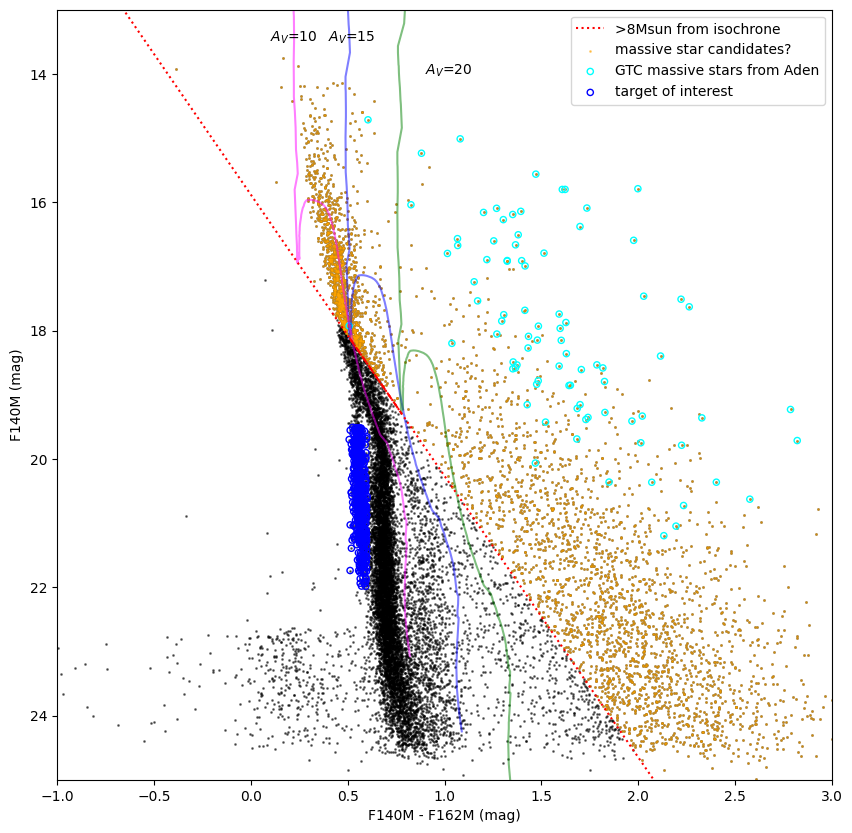

In [ ]:
spatial_idx1 = np.where((x>0.5) & (x<0.6) & (y>19.5) & (y<22))[0]


#F140 vs f140-f162
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
x = (f140m_mag[0]-f162m_mag[0]).value
y = f140m_mag[0].value
hb = ax1.scatter(x, y, s=1, color='k', alpha=0.5)
#cb = fig.colorbar(hb, ax=ax1, label='log(N)')
ax1.set_xlabel('F140M - F162M (mag)')
ax1.set_ylabel('F140M (mag)')
for i, age in enumerate(ageset):
    idx_age = logage_av0 == age

    ax1.plot((F140M_avmag_av0[idx_age]-F162M_avmag_av0[idx_age]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15), (F140M_avmag_av0[idx_age]+(ext(1/1.4/u.um))*15) , color='blue', alpha=0.5)
    ax1.plot((F140M_avmag_av0[idx_age]-F162M_avmag_av0[idx_age]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20), (F140M_avmag_av0[idx_age]+(ext(1/1.4/u.um))*20) , color='green', alpha=0.5)
    ax1.plot((F140M_avmag_av0[idx_age]-F162M_avmag_av0[idx_age]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*10), (F140M_avmag_av0[idx_age]+(ext(1/1.4/u.um))*10) , color='magenta', alpha=0.5)
    idx_8msun = np.argmin(np.abs(mass_av0[idx_age]-8))
    x_av15_8msun = F140M_avmag_av0[idx_age][idx_5msun]-F162M_avmag_av0[idx_age][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15
    y_av15_8msun = F140M_avmag_av0[idx_age][idx_5msun]+(ext(1/1.4/u.um))*15
    x_av20_8msun = F140M_avmag_av0[idx_age][idx_5msun]-F162M_avmag_av0[idx_age][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20
    y_av20_8msun = F140M_avmag_av0[idx_age][idx_5msun]+(ext(1/1.4/u.um))*20
    ax1.plot([x_av15_8msun, x_av20_8msun], [y_av15_8msun, y_av20_8msun], color='r', linestyle='dashed')
    slope = (y_av20_8msun - y_av15_8msun)/(x_av20_8msun - x_av15_8msun)
    y_intercept = y_av15_8msun - slope*x_av15_8msun
    ax1.plot([-1,3], [slope*-1 + y_intercept, slope*3 + y_intercept], color='r', linestyle='dotted',label='>8Msun from isochrone')

# plot scatter with differnet color for the point above the line
ax1.scatter(x[y < (slope*x + y_intercept)], y[y < (slope*x + y_intercept)], s=1, color='orange', alpha=0.5, label='massive star candidates?')

ax1.scatter(x[reverse_idx[real_reverse_matched]], y[reverse_idx[real_reverse_matched]], s=20, facecolor='none', edgecolor='cyan', label='GTC massive stars from Aden')
ax1.scatter(x[spatial_idx1], y[spatial_idx1], s=20, facecolor='none', edgecolor='blue', label='target of interest')
ax1.text(0.1,13.5, r'$A_V$=10')
ax1.text(0.4,13.5, r'$A_V$=15')
ax1.text(0.9,14, r'$A_V$=20')

ax1.set_xlim(-1,3)
ax1.set_ylim(25, 13)
ax1.legend()


Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
2025-10-08 20:25:40,099 - stpipe - WARNING - FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.537' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'.
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2025-10-08 20:25:40,102 - stpipe - WARNING - FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to  -106.570116 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'.


/scratch/local/14626337/ipykernel_3679456/835491231.py:7: RuntimeWarning: divide by zero encountered in log10
  ax1.imshow(np.log10(f140m_img), cmap='gray', norm=simple_norm(f140m_img, stretch='log', percent=99.9))
/scratch/local/14626337/ipykernel_3679456/835491231.py:7: RuntimeWarning: invalid value encountered in log10
  ax1.imshow(np.log10(f140m_img), cmap='gray', norm=simple_norm(f140m_img, stretch='log', percent=99.9))


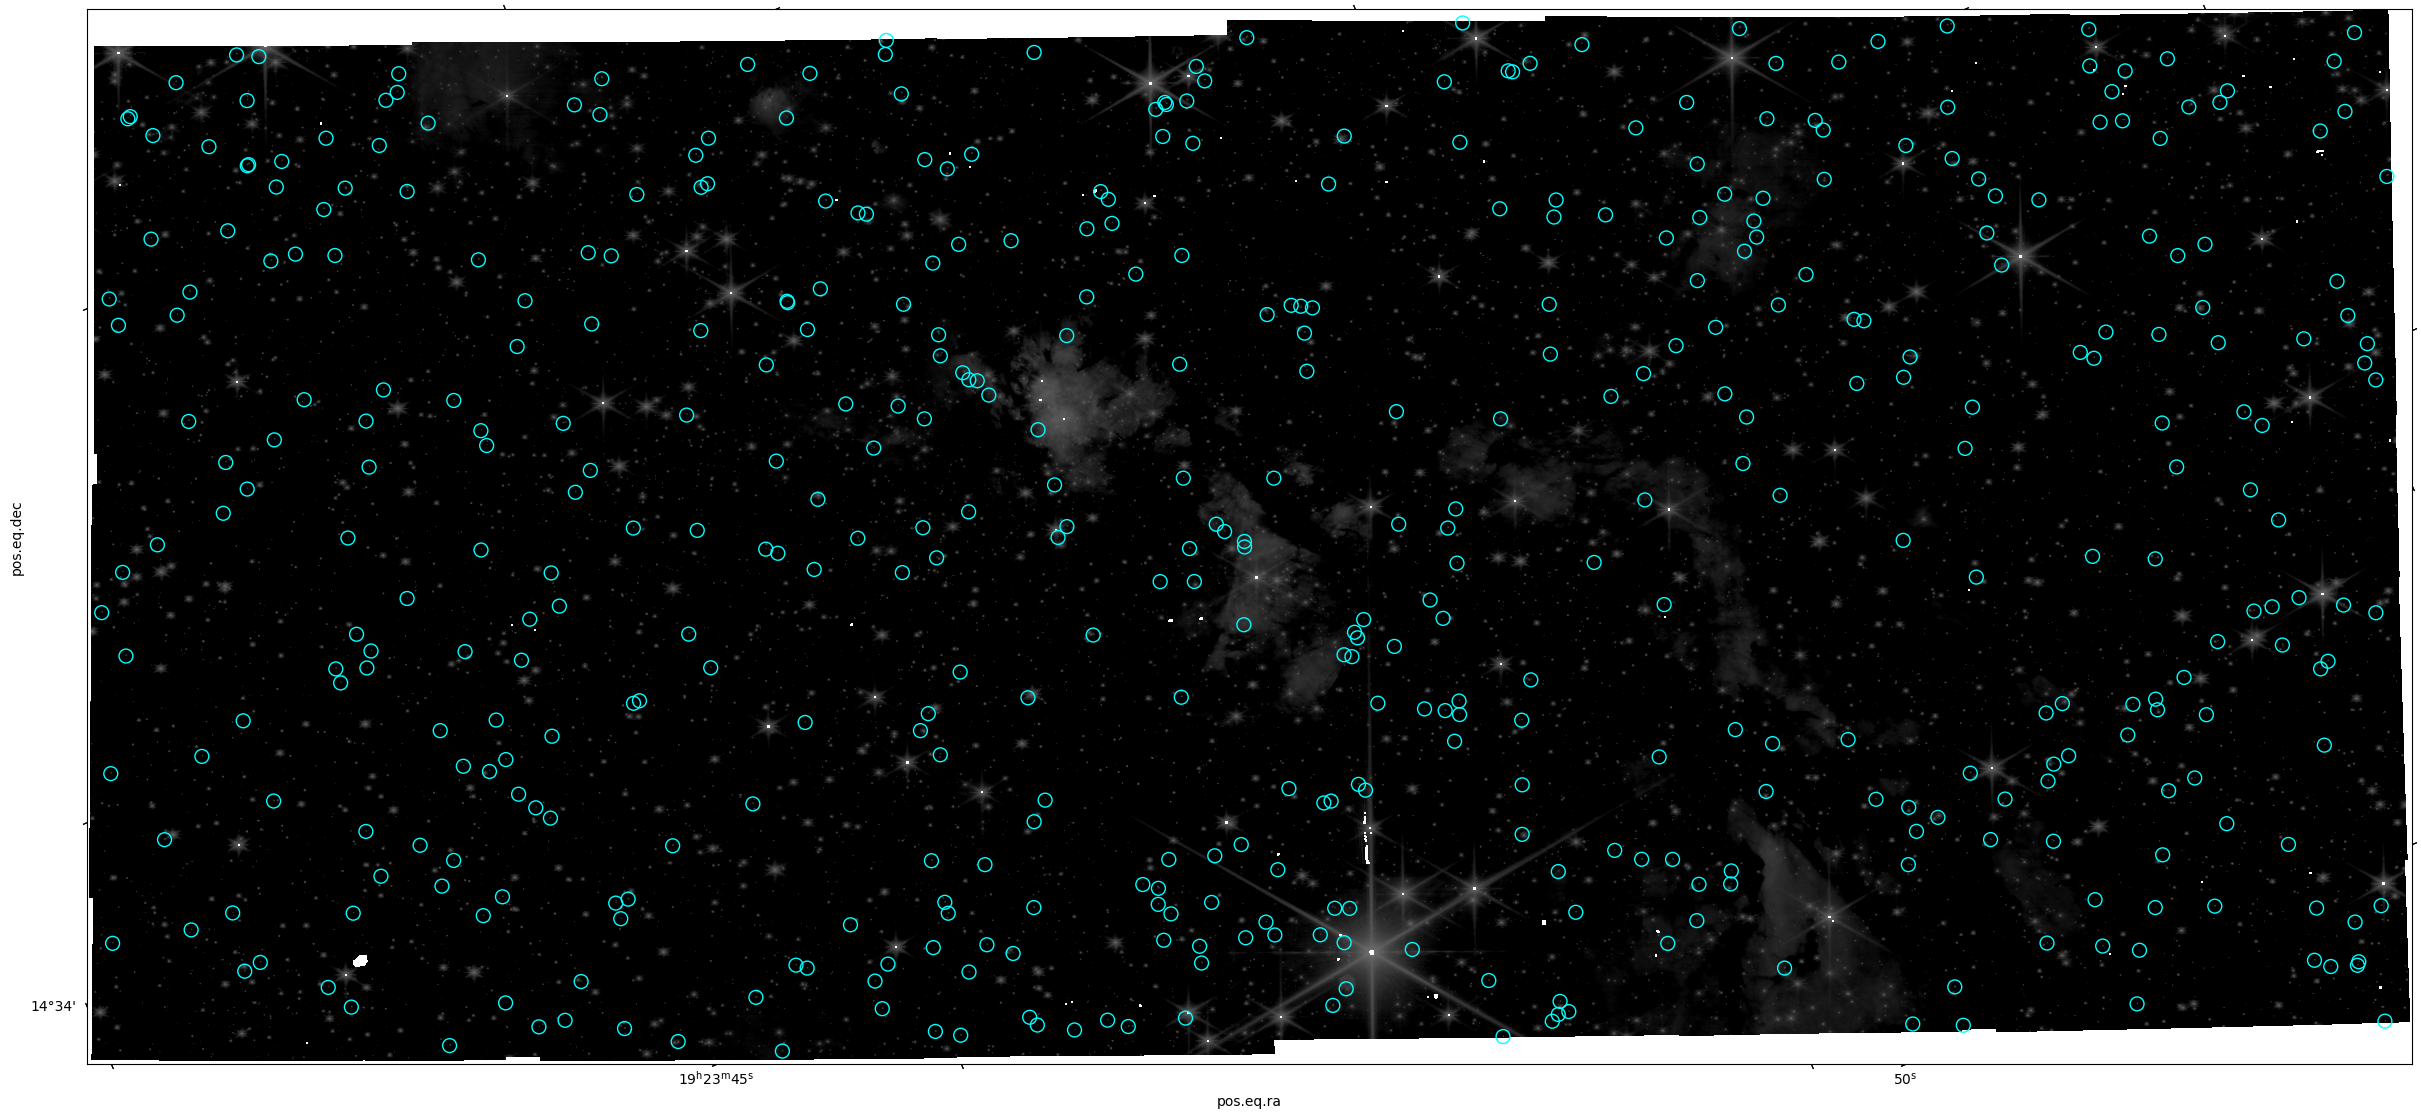

In [ ]:
from astropy.visualization import simple_norm

f140m_img = fits.getdata(image_filenames['f140m'], ext=('SCI', 1))
f140m_wcs = WCS(fits.getheader(image_filenames['f140m'], ext=('SCI', 1)))
fig = plt.figure(figsize=(30,15))
ax1 = fig.add_subplot(111, projection=f140m_wcs)
ax1.imshow(np.log10(f140m_img), cmap='gray', norm=simple_norm(f140m_img, stretch='log', percent=99.9))
ax1.scatter(catalog['skycoord'].ra[spatial_idx1], catalog['skycoord'].dec[spatial_idx1], transform=ax1.get_transform('world'), s=100, facecolor='none', edgecolor='cyan', label='target of interest')
tab_small_branch = Table()
tab_small_branch['ra'] = catalog['skycoord'].ra[spatial_idx1]
tab_small_branch['dec'] = catalog['skycoord'].dec[spatial_idx1]
tab_small_branch.write('/orange/adamginsburg/jwst/w51/small_branch_candidates_w51_jwst.fits', format='fits', overwrite=True)

Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
2025-10-08 20:25:48,538 - stpipe - WARNING - FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.537' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'.
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2025-10-08 20:25:48,542 - stpipe - WARNING - FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to  -106.570116 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'.


Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
2025-10-08 20:25:50,143 - stpipe - WARNING - FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.537' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'.
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2025-10-08 20:25:50,146 - stpipe - WARNING - FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to  -106.570116 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'.
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
2025-10-08 20:25:52,117 - stpipe - WARNING - FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.5

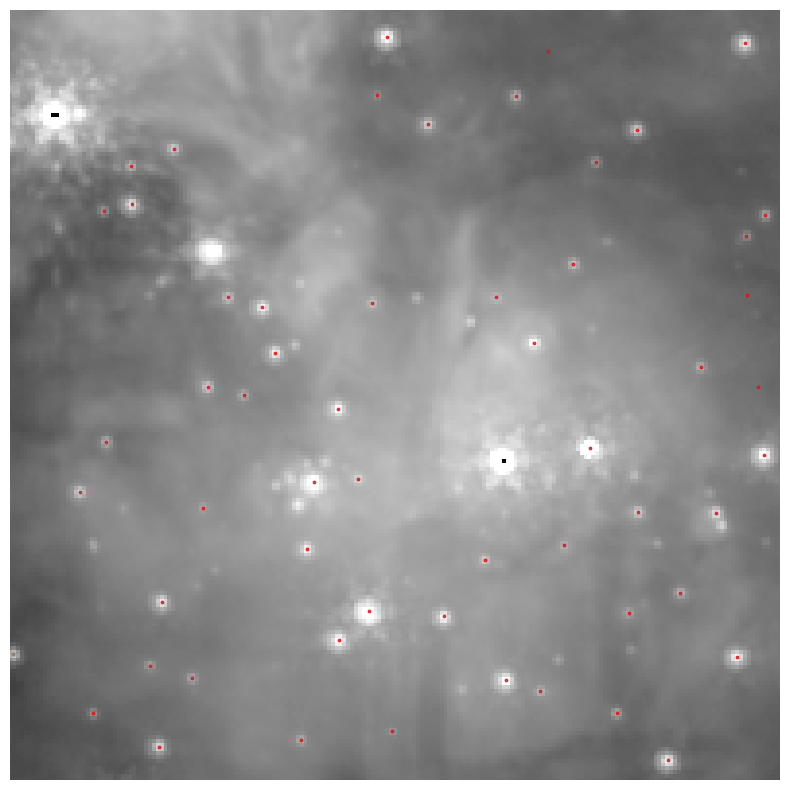

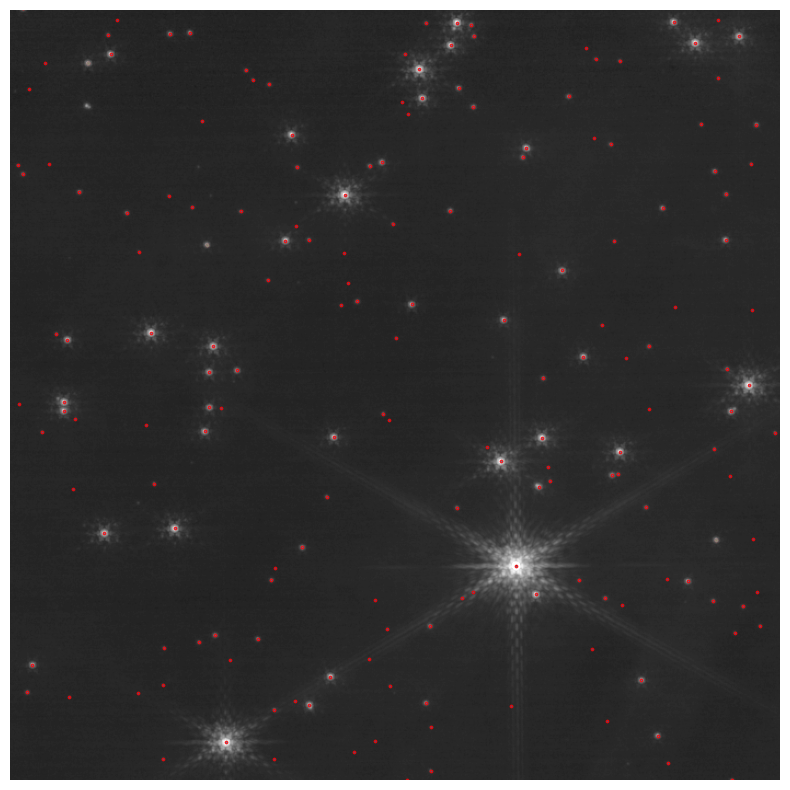

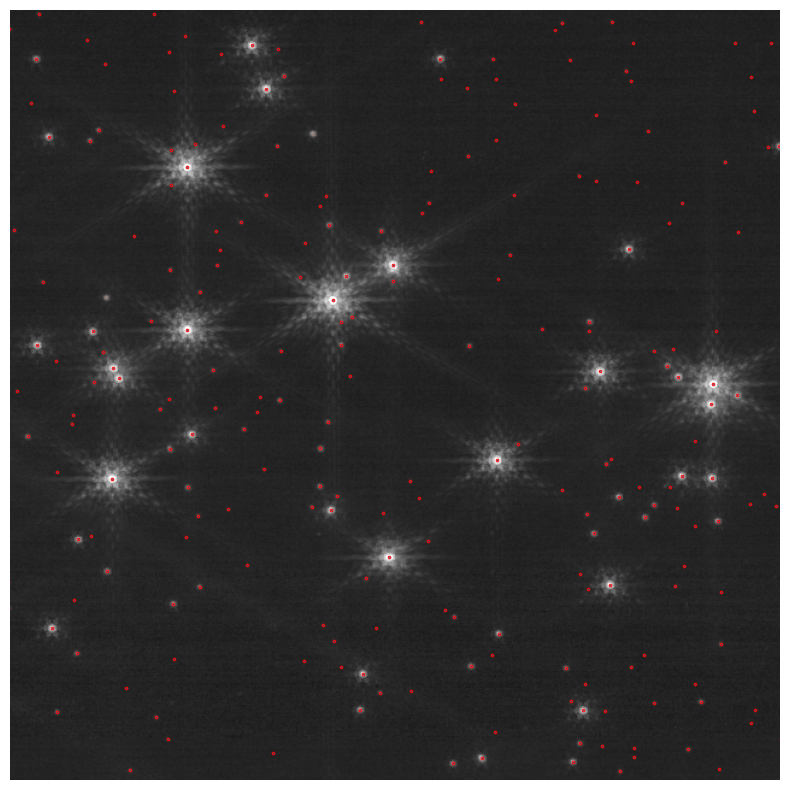

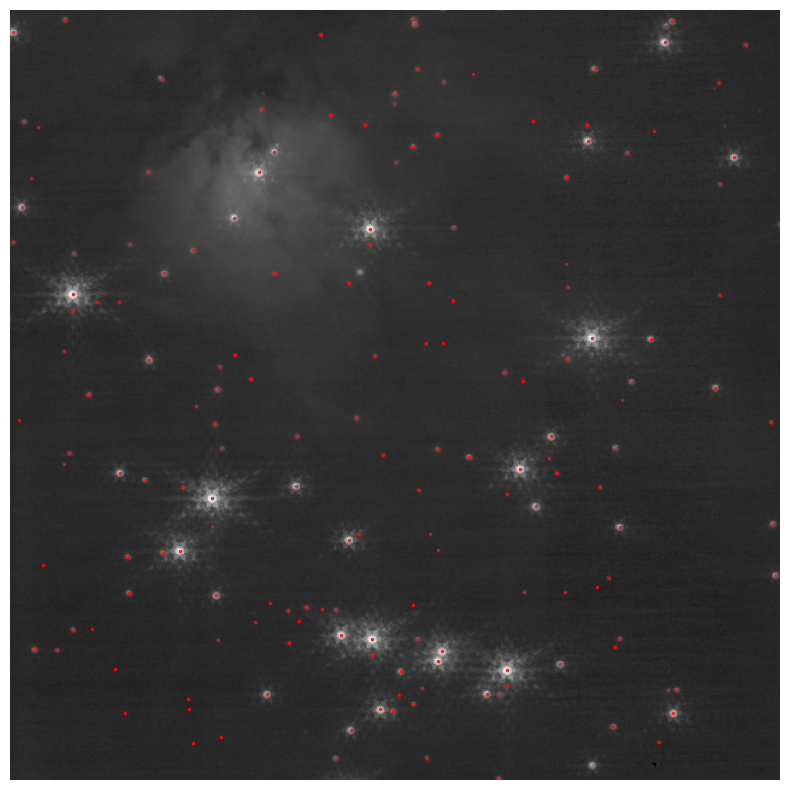

In [ ]:
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
from astropy.io import fits
from regions import Regions
test_regions = Regions.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/f140m_refine_test.reg', format='crtf')
for reg in test_regions:
    filename = image_filenames['f140m']
    hdu = fits.open(filename)
    data = hdu[1].data if len(hdu) > 1 else hdu[0].data
    wcs = WCS(hdu[1].header if len(hdu) > 1 else hdu[0].header)
    cutout = Cutout2D(data, reg.center, (reg.height, reg.width), wcs=wcs)
    norm = simple_norm(data, 'log', percent=99.95)
    fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': cutout.wcs})
    ax.imshow(cutout.data, norm=norm, origin='lower', cmap='gray')
    skycoord_ref = catalog['skycoord']
    
    #convert skycoordinates to pixel coordinates in the cutout
    pixcoords = cutout.wcs.world_to_pixel(skycoord_ref)
    ra = pixcoords[0]
    dec = pixcoords[1]
    ax.scatter(ra,dec, s=3, edgecolor='r', alpha=0.8)

    

    ra = pixcoords[0][spatial_idx1]
    dec = pixcoords[1][spatial_idx1]
    ax.scatter(ra, dec, s=3, edgecolor='cyan', alpha=0.4)
   
    ax.axis('off')
    ax.set_xlim(cutout.xmin_cutout, cutout.xmax_cutout)
    ax.set_ylim(cutout.ymin_cutout, cutout.ymax_cutout)

3865


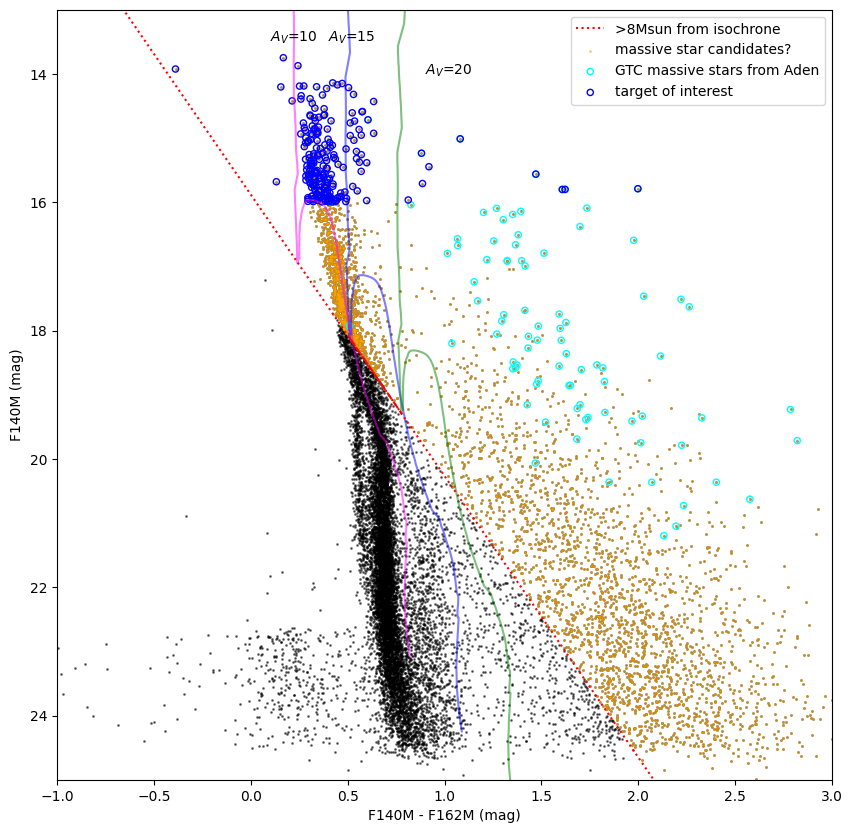

In [ ]:
spatial_idx2 = np.where((y<16))[0]


#F140 vs f140-f162
fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
x = (f140m_mag[0]-f162m_mag[0]).value
y = f140m_mag[0].value
hb = ax1.scatter(x, y, s=1, color='k', alpha=0.5)
#cb = fig.colorbar(hb, ax=ax1, label='log(N)')
ax1.set_xlabel('F140M - F162M (mag)')
ax1.set_ylabel('F140M (mag)')
for i, age in enumerate(ageset):
    idx_age = logage_av0 == age

    ax1.plot((F140M_avmag_av0[idx_age]-F162M_avmag_av0[idx_age]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15), (F140M_avmag_av0[idx_age]+(ext(1/1.4/u.um))*15) , color='blue', alpha=0.5)
    ax1.plot((F140M_avmag_av0[idx_age]-F162M_avmag_av0[idx_age]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20), (F140M_avmag_av0[idx_age]+(ext(1/1.4/u.um))*20) , color='green', alpha=0.5)
    ax1.plot((F140M_avmag_av0[idx_age]-F162M_avmag_av0[idx_age]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*10), (F140M_avmag_av0[idx_age]+(ext(1/1.4/u.um))*10) , color='magenta', alpha=0.5)
    idx_8msun = np.argmin(np.abs(mass_av0[idx_age]-8))
    x_av15_8msun = F140M_avmag_av0[idx_age][idx_5msun]-F162M_avmag_av0[idx_age][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*15
    y_av15_8msun = F140M_avmag_av0[idx_age][idx_5msun]+(ext(1/1.4/u.um))*15
    x_av20_8msun = F140M_avmag_av0[idx_age][idx_5msun]-F162M_avmag_av0[idx_age][idx_5msun]+(ext(1/1.4/u.um)-ext(1/1.62/u.um))*20
    y_av20_8msun = F140M_avmag_av0[idx_age][idx_5msun]+(ext(1/1.4/u.um))*20
    ax1.plot([x_av15_8msun, x_av20_8msun], [y_av15_8msun, y_av20_8msun], color='r', linestyle='dashed')
    slope = (y_av20_8msun - y_av15_8msun)/(x_av20_8msun - x_av15_8msun)
    y_intercept = y_av15_8msun - slope*x_av15_8msun
    ax1.plot([-1,3], [slope*-1 + y_intercept, slope*3 + y_intercept], color='r', linestyle='dotted',label='>8Msun from isochrone')

# plot scatter with differnet color for the point above the line
ax1.scatter(x[y < (slope*x + y_intercept)], y[y < (slope*x + y_intercept)], s=1, color='orange', alpha=0.5, label='massive star candidates?')
print(np.sum(y < (slope*x + y_intercept)))
ax1.scatter(x[reverse_idx[real_reverse_matched]], y[reverse_idx[real_reverse_matched]], s=20, facecolor='none', edgecolor='cyan', label='GTC massive stars from Aden')
ax1.scatter(x[spatial_idx2], y[spatial_idx2], s=20, facecolor='none', edgecolor='blue', label='target of interest')
ax1.text(0.1,13.5, r'$A_V$=10')
ax1.text(0.4,13.5, r'$A_V$=15')
ax1.text(0.9,14, r'$A_V$=20')

ax1.set_xlim(-1,3)
ax1.set_ylim(25, 13)
ax1.legend()


Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'. [astropy.wcs.wcs]
2025-10-08 20:25:57,771 - stpipe - WARNING - FITSFixedWarning: 'datfix' made the change 'Set DATE-BEG to '2025-05-06T16:37:42.537' from MJD-BEG.
Set DATE-AVG to '2025-05-06T16:59:22.406' from MJD-AVG.
Set DATE-END to '2025-05-06T17:21:22.408' from MJD-END'.
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
2025-10-08 20:25:57,774 - stpipe - WARNING - FITSFixedWarning: 'obsfix' made the change 'Set OBSGEO-L to  -106.570116 from OBSGEO-[XYZ].
Set OBSGEO-B to   -25.271881 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611441536.798 from OBSGEO-[XYZ]'.


/scratch/local/14626337/ipykernel_3679456/1338638409.py:7: RuntimeWarning: divide by zero encountered in log10
  ax1.imshow(np.log10(f140m_img), cmap='gray', norm=simple_norm(f140m_img, stretch='log', percent=99.9))
/scratch/local/14626337/ipykernel_3679456/1338638409.py:7: RuntimeWarning: invalid value encountered in log10
  ax1.imshow(np.log10(f140m_img), cmap='gray', norm=simple_norm(f140m_img, stretch='log', percent=99.9))


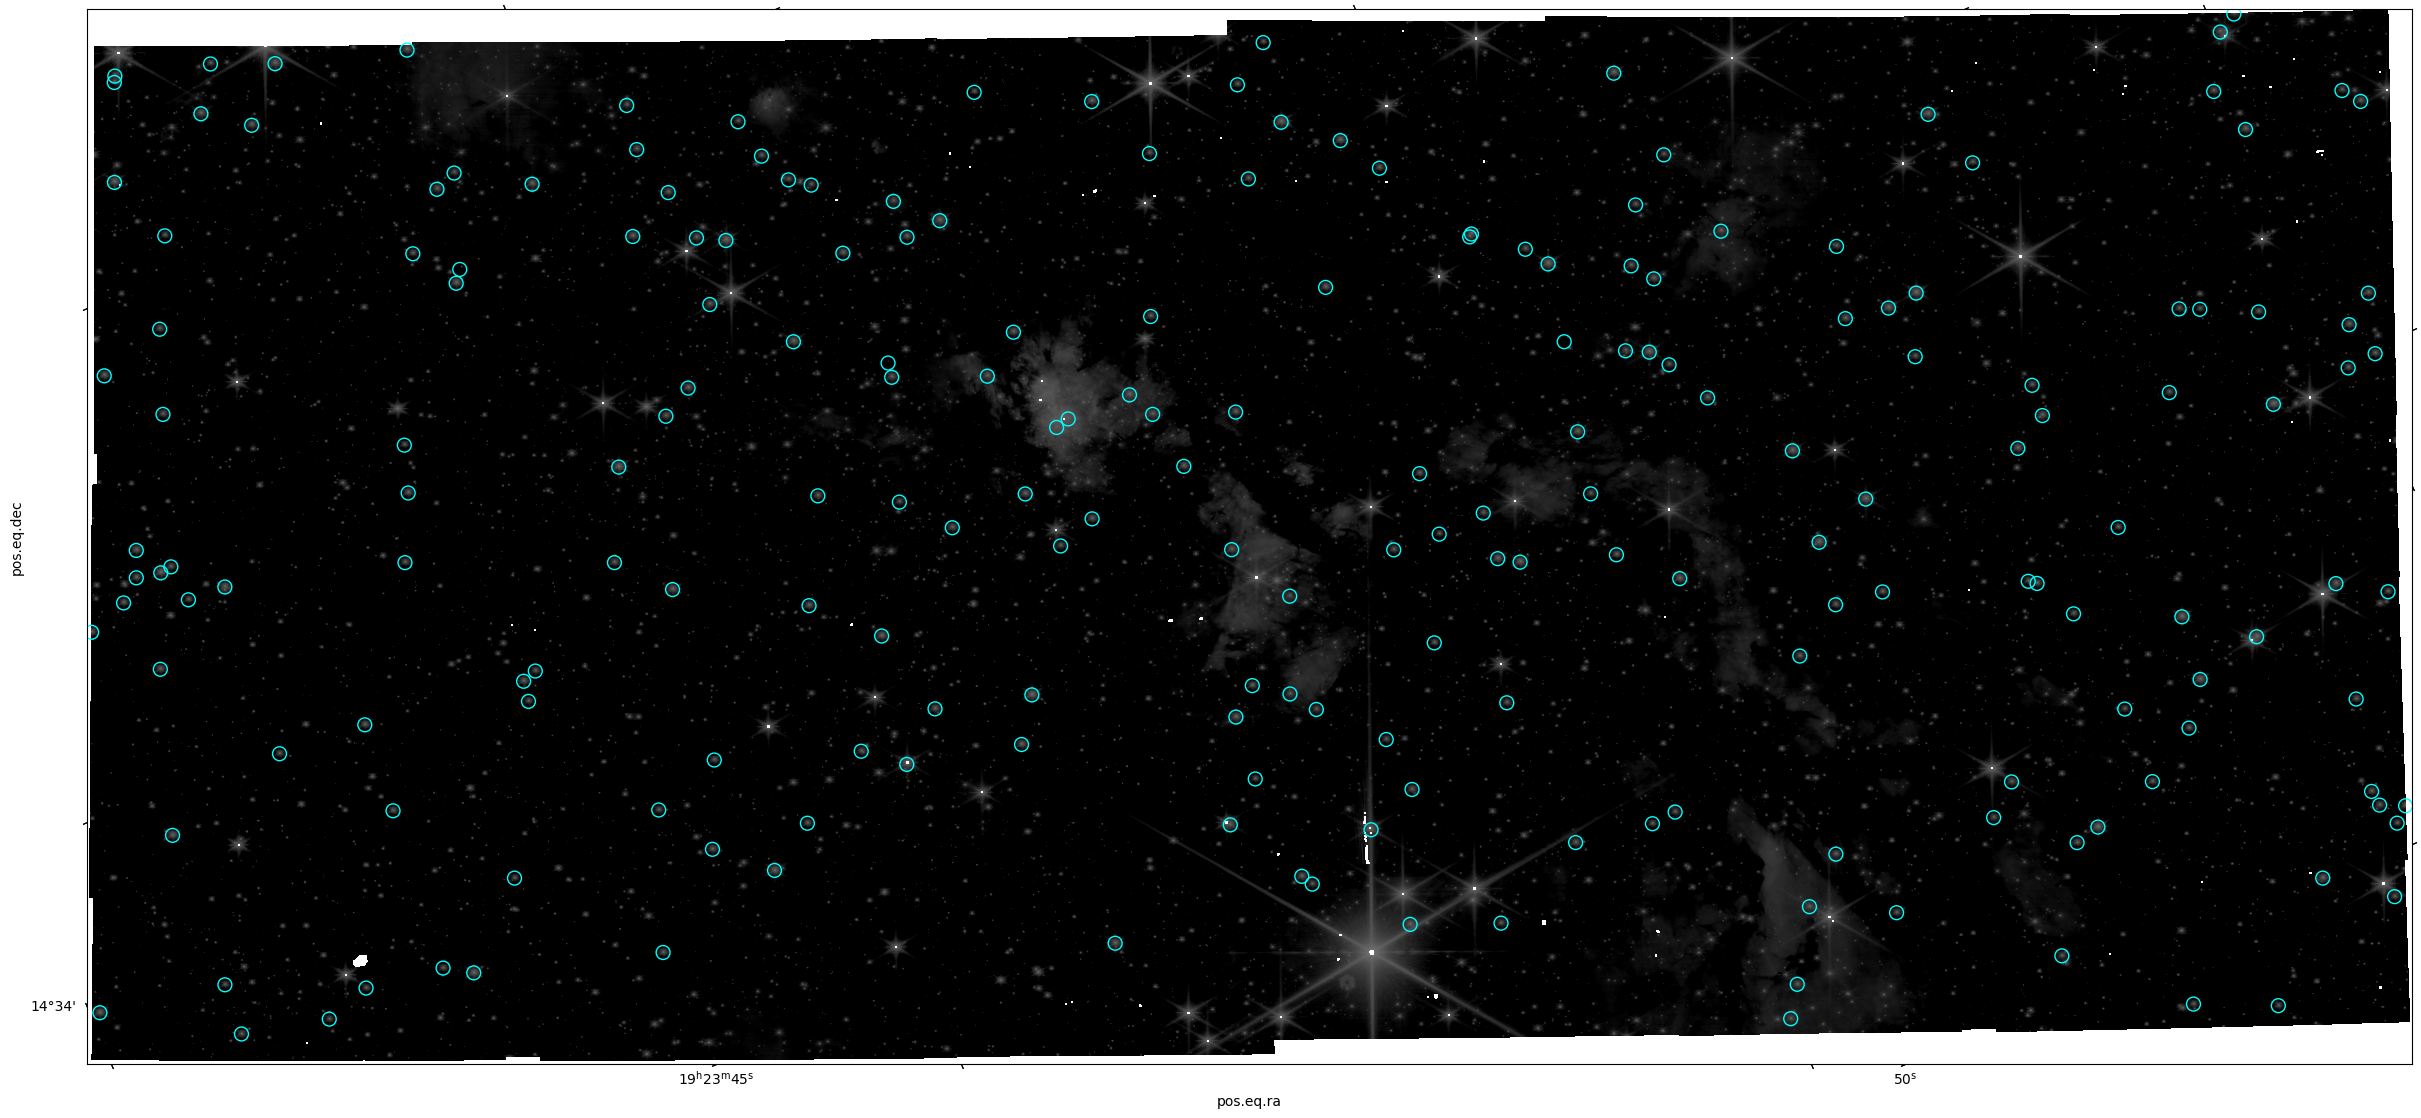

In [ ]:
from astropy.visualization import simple_norm

f140m_img = fits.getdata(image_filenames['f140m'], ext=('SCI', 1))
f140m_wcs = WCS(fits.getheader(image_filenames['f140m'], ext=('SCI', 1)))
fig = plt.figure(figsize=(30,15))
ax1 = fig.add_subplot(111, projection=f140m_wcs)
ax1.imshow(np.log10(f140m_img), cmap='gray', norm=simple_norm(f140m_img, stretch='log', percent=99.9))
ax1.scatter(catalog['skycoord'].ra[spatial_idx2], catalog['skycoord'].dec[spatial_idx2], transform=ax1.get_transform('world'), s=100, facecolor='none', edgecolor='cyan', label='target of interest')
tab_bright_in_f140m = Table()
tab_bright_in_f140m['ra'] = catalog['skycoord'].ra[spatial_idx2]
tab_bright_in_f140m['dec'] = catalog['skycoord'].dec[spatial_idx2]
tab_bright_in_f140m.write('/orange/adamginsburg/jwst/w51/bright_in_f140m_candidates_w51_jwst.fits', format='fits', overwrite=True)

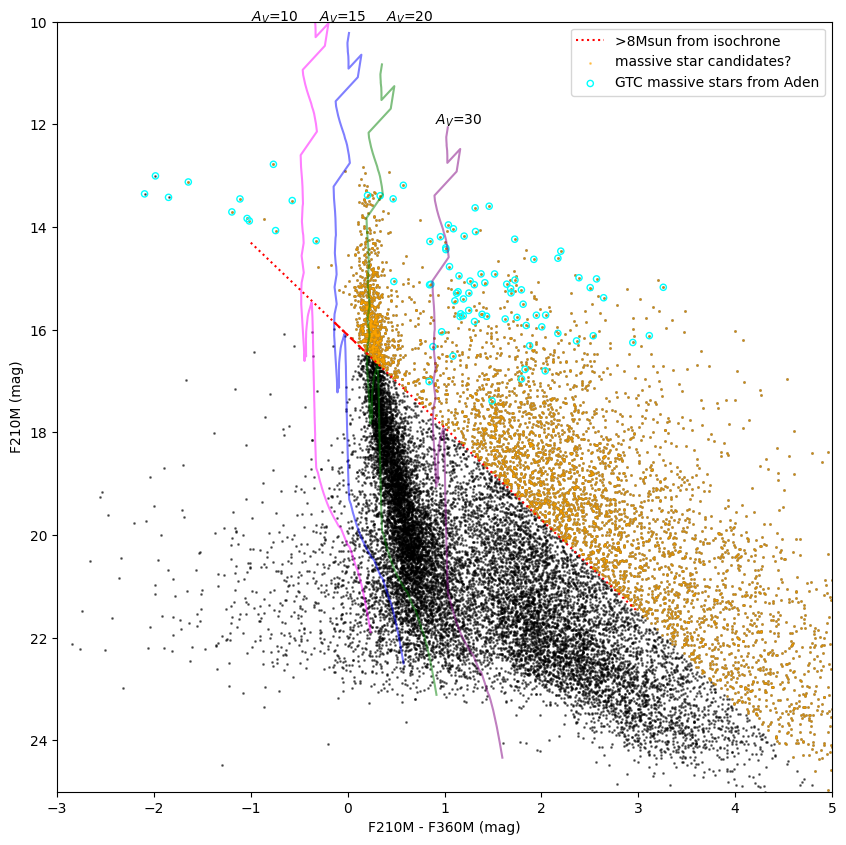

In [ ]:


#F210 vs F210-F360

fig = plt.figure(figsize=(10,10))
ax1 = fig.add_subplot(111)
x = (f210m_mag[0]-f360m_mag[0]).value
y = f210m_mag[0].value
hb = ax1.scatter(x, y, s=1, color='k', alpha=0.5)
#cb = fig.colorbar(hb, ax=ax1, label='log(N)')
ax1.set_xlabel('F210M - F360M (mag)')
ax1.set_ylabel('F210M (mag)')
for i, age in enumerate(ageset):
    idx_age = logage_av0 == age

    ax1.plot((F210M_avmag_av0[idx_age]-F360M_avmag_av0[idx_age]+(ext(1/2.1/u.um)-ext(1/3.6/u.um))*15), (F210M_avmag_av0[idx_age]+(ext(1/2.1/u.um))*15) , color='blue', alpha=0.5)
    ax1.plot((F210M_avmag_av0[idx_age]-F360M_avmag_av0[idx_age]+(ext(1/2.1/u.um)-ext(1/3.6/u.um))*20), (F210M_avmag_av0[idx_age]+(ext(1/2.1/u.um))*20) , color='green', alpha=0.5)
    ax1.plot((F210M_avmag_av0[idx_age]-F360M_avmag_av0[idx_age]+(ext(1/2.1/u.um)-ext(1/3.6/u.um))*10), (F210M_avmag_av0[idx_age]+(ext(1/2.1/u.um))*10) , color='magenta', alpha=0.5)
    ax1.plot((F210M_avmag_av0[idx_age]-F360M_avmag_av0[idx_age]+(ext(1/2.1/u.um)-ext(1/3.6/u.um))*30), (F210M_avmag_av0[idx_age]+(ext(1/2.1/u.um))*30) , color='purple', alpha=0.5)
    idx_10msun = np.argmin(np.abs(mass_av0[idx_age]-10))
    x_av15_10msun = F210M_avmag_av0[idx_age][idx_10msun]-F360M_avmag_av0[idx_age][idx_10msun]+(ext(1/2.1/u.um)-ext(1/3.6/u.um))*15
    y_av15_10msun = F210M_avmag_av0[idx_age][idx_10msun]+(ext(1/2.1/u.um))*15
    x_av20_10msun = F210M_avmag_av0[idx_age][idx_10msun]-F360M_avmag_av0[idx_age][idx_10msun]+(ext(1/2.1/u.um)-ext(1/3.6/u.um))*20
    y_av20_10msun = F210M_avmag_av0[idx_age][idx_10msun]+(ext(1/2.1/u.um))*20
    ax1.plot([x_av15_10msun, x_av20_10msun], [y_av15_10msun, y_av20_10msun], color='r', linestyle='dashed')
    slope = (y_av20_10msun - y_av15_10msun)/(x_av20_10msun - x_av15_10msun)
    y_intercept = y_av15_10msun - slope*x_av15_10msun
    ax1.plot([-1,3], [slope*-1 + y_intercept, slope*3 + y_intercept], color='r', linestyle='dotted',label='>8Msun from isochrone')

# plot scatter with differnet color for the point above the line
ax1.scatter(x[y < (slope*x + y_intercept)], y[y < (slope*x + y_intercept)], s=1, color='orange', alpha=0.5, label='massive star candidates?')

ax1.scatter(x[reverse_idx[real_reverse_matched]], y[reverse_idx[real_reverse_matched]], s=20, facecolor='none', edgecolor='cyan', label='GTC massive stars from Aden')
#ax1.scatter(x[spatial_idx1], y[spatial_idx1], s=20, facecolor='none', edgecolor='blue', label='target of interest')
ax1.text(-1,10, r'$A_V$=10')
ax1.text(-0.3,10, r'$A_V$=15')

ax1.text(0.4,10, r'$A_V$=20')
ax1.text(0.9,12, r'$A_V$=30')

ax1.set_xlim(-3,5)
ax1.set_ylim(25, 10)
ax1.legend()
